
### Program: Chemostat Model
#### Author: C.D. Wentworth + Johang Hernandez

*Version: 3.23.2026.1*

Summary: \
    This program implements a dynamical systems model of a
    chemostat that uses one growth-limiting nutrient and
    produces one species of bacteria. The model is expressed in
    a dimensionless form. It then outputs a table comparing different a1 values and their resulting steady state and time to steady state values.

<details>
    <summary>Version History:</summary>
    <ul>
        <li>3.23.2026.1: Added tables and graphs comparing different a1 values</li>
        <li>8.22.2022.1: base</li>
    </ul>
</details>


### Original Program

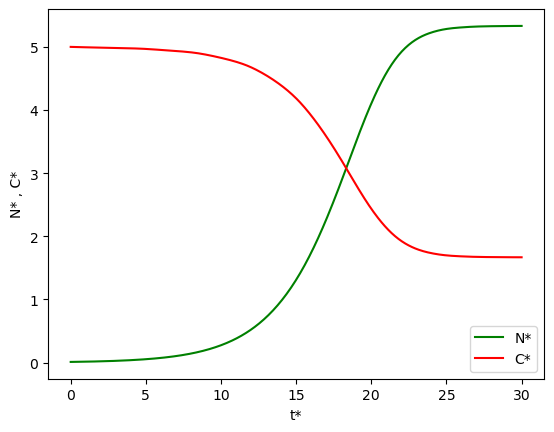

In [56]:
import scipy.integrate as si
import numpy as np
import matplotlib.pylab as plt

# Create a function that defines the rhs of the differential equation system

def f(t, y, a1, a2):
    #   y = a list that contains the system state
    #   t = the time for which the right-hand-side of the system equations
    #       is to be calculated.
    #   a1 = a parameter needed for the model
    #   a2 = a paramteter needed for the model

    #   Unpack the state of the system
    y0 = y[0]  # N*
    y1 = y[1]  # C*

    #   Calculate the rates of change (the derivatives)
    dy0dt = a1*(y1/(1.0 + y1))*y0 - y0
    dy1dt = -(y1/(1.0 + y1))*y0 - y1 + a2

    return [dy0dt, dy1dt]


# Main Program

# Define the initial conditions
yi = [0.01, 5.0]

# Define the time grid
ti = 0.0
tf = 30.0
t = np.linspace(ti, tf, 400)

# Define the parameter tuple
#a1 = 2.6  #
a1 = 1.6
a2 = 5.0  #
p = (a1, a2)

# Solve the DE
sol = si.solve_ivp(f, (ti, tf), yi, t_eval=t, args=p)
N = sol.y[0]
C = sol.y[1]

# Plot the solution
plt.plot(t, N, color='green', label='N*')
plt.plot(t, C, color='red', label='C*')
plt.xlabel('t*')
plt.ylabel('N* , C*')
plt.legend()
plt.savefig('chemostat.png')
plt.show()

### Part 1

In [64]:
a1_values = np.linspace(1.6, 2.6, 6)
ss_results = []
time_results = []

# Define the initial conditions
yi = [0.01, 5.0]

# Define the time grid
ti = 0.0
tf = 30.0
t = np.linspace(ti, tf, 400)

a2 = 5.0


print(f"| a1 | Steady-State N* | Time to Steady-State |")
print(f"|---|---|---|")
# Define the parameter tuple
for a1 in a1_values:

    #print(a1)

    p = (a1, a2)

    # Solve the DE
    sol = si.solve_ivp(f, (ti, tf), yi, t_eval=t, args=p)
    N = sol.y[0]

    steady_state = N[-1]

    # return the first time where N reaches 99% of the max, the state where most change has stopped
    idx = np.where(N >= 0.99*steady_state)[0][0]

    time = t[idx]

    ss_results.append(steady_state)
    time_results.append(time)

    print(f"| {a1:.1f} | {steady_state:.2f} | {time:.2f} |")


| a1 | Steady-State N* | Time to Steady-State |
|---|---|---|
| 1.6 | 5.33 | 24.89 |
| 1.8 | 6.75 | 16.47 |
| 2.0 | 8.00 | 12.33 |
| 2.2 | 9.17 | 9.92 |
| 2.4 | 10.29 | 8.27 |
| 2.6 | 11.37 | 7.14 |


| a1 | Steady-State N* | Time to Steady-State |
|---|---|---|
| 1.6 | 5.33 | 24.89 |
| 1.8 | 6.75 | 16.47 |
| 2.0 | 8.00 | 12.33 |
| 2.2 | 9.17 | 9.92 |
| 2.4 | 10.29 | 8.27 |
| 2.6 | 11.37 | 7.14 |

### Part 2

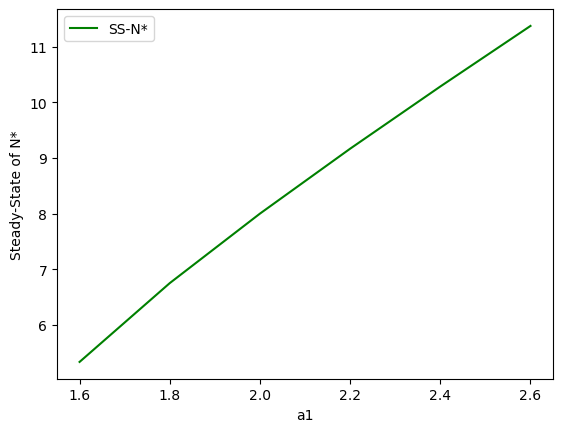

In [62]:
plt.plot(a1_values, ss_results, color='green', label='SS-N*')
plt.xlabel('a1')
plt.ylabel('Steady-State of N*')
plt.legend()
plt.savefig('ss_v_a1.png')
plt.show()

### Part 3

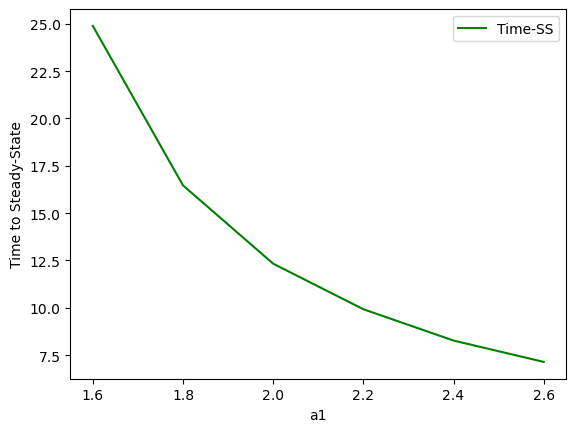

In [65]:
plt.plot(a1_values, time_results, color='green', label='Time-SS')
plt.xlabel('a1')
plt.ylabel('Time to Steady-State')
plt.legend()
plt.savefig('time_ss_v_a1.png')
plt.show()